# 1. Problem Framing

**Objective**

- What are we forecasting? (e.g. daily unit sales)
- At what granularity? (item-store, SKU, etc.) — here: (store_id, item_id) per day
- Forecast horizon? (e.g. 1–28 days ahead)

**Target Variable**

- **Definition:** Daily sales (units sold) for each (store_id, item_id)
- **Units:** Count (integer)
- **Business meaning:** Demand realization; zeros are valid (no sale that day)

*This notebook uses a sampled subset of the M5 dataset (1 store × 200 items) for reproducibility.*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Reusable EDA template (retail / demand forecasting). Flow: validate, distribution, intermittency, temporal structure, drivers, heterogeneity, modeling implications, summary.


## Setup

In [43]:
def find_repo_root(
    marker_files=("README.md", "pyproject.toml", "requirements.txt")
) -> Path:
    """
    Walk up from the current directory until we find a repo root marker.
    """
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if any((parent / m).exists() for m in marker_files):
            return parent
    raise FileNotFoundError(
        "Could not find repo root. Run this notebook inside the project folder "
        "or ensure README.md/requirements.txt exists at repo root."
    )


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "m5_daily_sample.parquet"
DATA_PATH

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPO_ROOT

WindowsPath('C:/Users/imanb/retail_demand/retail-demand-forecasting-delayed-labels')

## Data loading

In [44]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing file: {DATA_PATH}\n\n"
        "Run preprocessing first:\n"
        "python src/data/preprocess.py "
        "--sample_stores 1 --sample_items 200 "
        "--out_path data/processed/m5_daily_sample.parquet"
    )

print("Repo root:", REPO_ROOT)
print("Data path:", DATA_PATH)

df = pd.read_parquet(DATA_PATH)
df.info()
df.head()

Repo root: C:\Users\imanb\retail_demand\retail-demand-forecasting-delayed-labels
Data path: C:\Users\imanb\retail_demand\retail-demand-forecasting-delayed-labels\data\processed\m5_daily_sample.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382600 entries, 0 to 382599
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          382600 non-null  datetime64[ns]
 1   d             382600 non-null  object        
 2   wm_yr_wk      382600 non-null  int64         
 3   item_id       382600 non-null  object        
 4   dept_id       382600 non-null  object        
 5   cat_id        382600 non-null  object        
 6   store_id      382600 non-null  object        
 7   state_id      382600 non-null  object        
 8   sales         382600 non-null  int64         
 9   sell_price    324024 non-null  float64       
 10  event_name_1  30800 non-null   object        
 11  event_type_1  30800 

,date,d,wm_yr_wk,item_id,dept_id,cat_id,store_id,state_id,sales,sell_price,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,d_1,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,3,2.0,None,None,None,None,0,0,0
1,2011-01-30,d_2,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2.0,None,None,None,None,0,0,0
2,2011-01-31,d_3,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2.0,None,None,None,None,0,0,0
3,2011-02-01,d_4,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2.0,None,None,None,None,1,1,0
4,2011-02-02,d_5,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,4,2.0,None,None,None,None,1,0,1


### Data overview

The dataset represents daily item-level sales with calendar and pricing context.
Each row corresponds to a `(store_id, item_id, date)` combination.

### Row definition
Each row represents a single daily observation for a specific `(store_id, item_id, date)` with sales (target) and joined context from:
- calendar features (events, SNAP flags)
- weekly sell price (when available)


# 2. Data Integrity & Structural Validation

## 2.1 Schema validation
Required columns, data types (see Data loading / overview).

## 2.2 Key uniqueness
Check (store_id, item_id, date) uniqueness.

## 2.3 Time continuity
Daily continuity per series; missing date gaps.

## 2.4 Structural missingness
See missingness table and sell_price null validation (structural = pre-introduction).

In [45]:
# 1) Key uniqueness
key_cols = ["store_id", "item_id", "date"]
dup_rate = df.duplicated(key_cols).mean()
print("Duplicate key rate:", dup_rate)

# 2) Date continuity within a series (spot check)
one_series = (
    df.groupby(["store_id", "item_id"]).size().sort_values(ascending=False).index[0]
)
ts = df[
    (df["store_id"] == one_series[0]) & (df["item_id"] == one_series[1])
].sort_values("date")
missing_days = ts["date"].diff().dt.days.dropna().value_counts().sort_index()
print("Most common day gaps (should be mostly 1):")
print(missing_days.head(10))

# 3) Sales validity
print("Any negative sales?", (df["sales"] < 0).any())
print("Sales dtype:", df["sales"].dtype)

# 4) Basic counts for context
print("Rows:", len(df))
print("Stores:", df["store_id"].nunique(), "| Items:", df["item_id"].nunique())
print("Date range:", df["date"].min(), "->", df["date"].max())

Duplicate key rate: 0.0
Most common day gaps (should be mostly 1):
date
1.0    1912
Name: count, dtype: int64
Any negative sales? False
Sales dtype: int64
Rows: 382600
Stores: 1 | Items: 200
Date range: 2011-01-29 00:00:00 -> 2016-04-24 00:00:00


**Output: Integrity validation summary**

Key validation results:

- **Uniqueness:**  
  No duplicate records were found for the `(store_id, item_id, date)` key  
  *(duplicate rate = 0.0)*, confirming a one-row-per-day structure per item.

- **Temporal continuity:**  
  The most common gap between consecutive dates is **1 day**, indicating a
  complete and continuous daily time series with no missing dates.

- **Target validity:**  
  - No negative sales values were observed.
  - `sales` is stored as an integer type, consistent with count data.

- **Dataset scope:**  
  - **Rows:** 382,600  
  - **Stores:** 1  
  - **Items:** 200  
  - **Date range:** 2011-01-29 → 2016-04-24  

**Conclusion:**  
The dataset satisfies key integrity assumptions required for time-series
forecasting. There are no structural issues related to duplication, missing
dates, or invalid target values. The data is suitable for downstream modeling
and evaluation without corrective preprocessing at this stage.


# 3. Target Distribution Analysis

## 3.1 Global distribution
Histogram of sales; log-scale optional; mean vs variance.

## 3.2 Zero-inflation
Global zero rate; % zero per series (distribution).

## 3.3 Overdispersion check
Compare mean vs variance; justify non-Gaussian modeling.

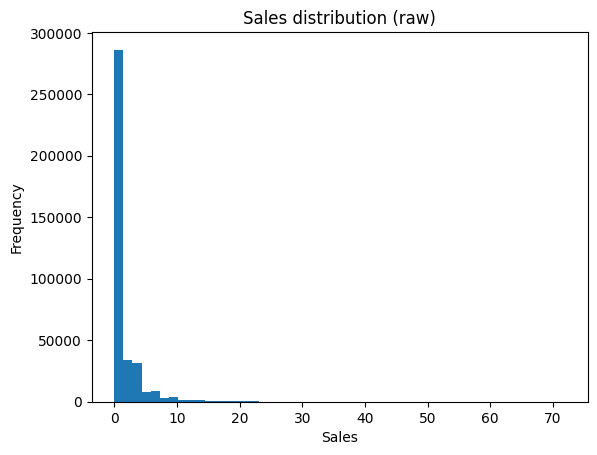

In [46]:
# Sales distribution
df["sales"].plot(kind="hist", bins=50, title="Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales distribution (raw)")
plt.show()

In [47]:
plt.savefig(FIG_DIR / "sales_hist.png", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [48]:
df["sales"].describe()

count    382600.000000
mean          1.335868
std           2.936366
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          72.000000
Name: sales, dtype: float64

In [49]:
(df["sales"] == 0).mean()

np.float64(0.5987872451646629)

**Output: Is Gaussian assumption valid?**

Key observations:
- ~60% of daily observations have zero sales (strong zero-inflation).
- Distribution is highly right-skewed with demand spikes.
- Sales are discrete, non-negative; zeros are valid, not missing.

Implications: Gaussian inappropriate; use count / intermittent-aware models. Prefer MAE / sMAPE over RMSE; include seasonal naïve or moving-average baselines.


# 8. Cross-Series Heterogeneity

## 8.1 Mean / median / max distribution
Per-series statistics and their distributions across items.

## 8.2 Volume segmentation
Low / mid / high volume (e.g. by % zero or mean sales).

## 8.3 Representative series inspection
Pick representative series for detailed plots (below).

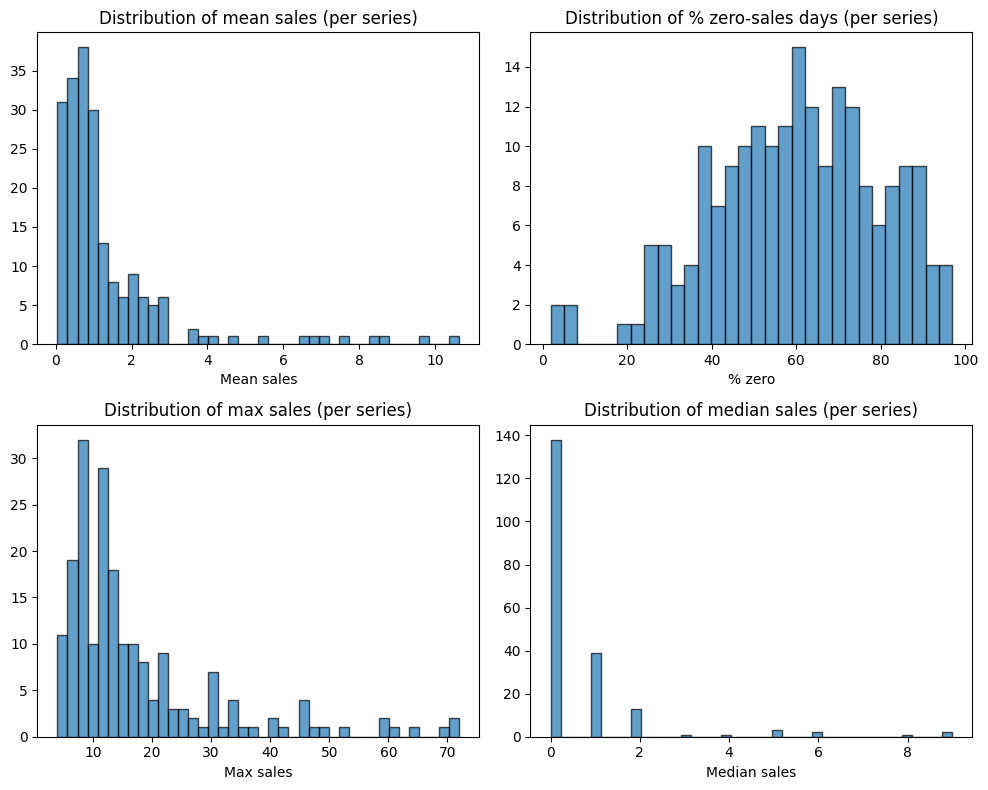

       mean_sales  median_sales   max_sales   std_sales    pct_zero
count  200.000000    200.000000  200.000000  200.000000  200.000000
mean     1.335868      0.625000   17.275000    1.845876   59.878725
std      1.682633      1.436906   13.574265    1.553373   19.772383
min      0.042865      0.000000    4.000000    0.265212    1.881861
25%      0.460533      0.000000    9.000000    0.995365   47.164140
50%      0.819394      0.000000   12.000000    1.359563   59.984318
75%      1.511631      1.000000   20.000000    2.004606   74.451124
max     10.641924      9.000000   72.000000    8.866217   96.915839


In [ ]:
# Per-series statistics (population-level)
pct_zero = (
    df.groupby(["store_id", "item_id"])["sales"]
    .apply(lambda s: (s == 0).mean() * 100)
    .reset_index(name="pct_zero")
)
agg = (
    df.groupby(["store_id", "item_id"])["sales"]
    .agg(["mean", "median", "max", "std"])
    .reset_index()
)
series_stats_full = agg.merge(pct_zero, on=["store_id", "item_id"])
series_stats_full.columns = [
    "store_id",
    "item_id",
    "mean_sales",
    "median_sales",
    "max_sales",
    "std_sales",
    "pct_zero",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(series_stats_full["mean_sales"], bins=40, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of mean sales (per series)")
axes[0, 0].set_xlabel("Mean sales")
axes[0, 1].hist(series_stats_full["pct_zero"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Distribution of % zero-sales days (per series)")
axes[0, 1].set_xlabel("% zero")
axes[1, 0].hist(series_stats_full["max_sales"], bins=40, edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Distribution of max sales (per series)")
axes[1, 0].set_xlabel("Max sales")
axes[1, 1].hist(
    series_stats_full["median_sales"], bins=40, edgecolor="black", alpha=0.7
)
axes[1, 1].set_title("Distribution of median sales (per series)")
axes[1, 1].set_xlabel("Median sales")
plt.tight_layout()
plt.show()
print(series_stats_full.describe())


### Section 8 narrative

Most series have very low average demand (long-tail); volume segmentation and representative series support modeling choices.

The percentage of zero-sales days is high across most series (commonly 40–85%), and median sales are frequently zero. This confirms that the dataset exhibits substantial intermittent and zero-inflated demand.

Maximum sales display a heavy-tailed distribution, suggesting occasional demand spikes likely driven by promotions or seasonal effects. Variance appears significantly larger than the mean across many series, indicating overdispersion.

### Implications

The demand process is sparse, skewed, and heterogeneous across series. Gaussian assumptions are inappropriate. Flexible, non-linear modeling approaches (e.g., tree-based or count-aware objectives) are better suited for this retail forecasting problem.


In [51]:
# Pick representative series by intermittency (low / medium / high % zeros)
q_low = series_stats_full["pct_zero"].quantile(0.25)
q_high = series_stats_full["pct_zero"].quantile(0.75)
rep_low = series_stats_full.loc[series_stats_full["pct_zero"] <= q_low].nsmallest(
    2, "pct_zero"
)
rep_mid = series_stats_full.loc[
    (series_stats_full["pct_zero"] > q_low) & (series_stats_full["pct_zero"] < q_high)
].sample(2, random_state=42)
rep_high = series_stats_full.loc[series_stats_full["pct_zero"] >= q_high].nlargest(
    2, "pct_zero"
)
representative_series = pd.concat([rep_low, rep_mid, rep_high]).drop_duplicates(
    subset=["store_id", "item_id"]
)
print("Representative series (for detailed plots): low / mid / high % zero")
print(
    representative_series[["store_id", "item_id", "pct_zero", "mean_sales"]].to_string(
        index=False
    )
)

Representative series (for detailed plots): low / mid / high % zero
store_id     item_id  pct_zero  mean_sales
    CA_1 FOODS_1_085  1.881861   10.641924
    CA_1 FOODS_1_018  2.770518    9.706221
    CA_1 FOODS_1_175 59.226346    0.767381
    CA_1 FOODS_1_119 72.817564    0.438055
    CA_1 FOODS_1_079 96.915839    0.042865
    CA_1 FOODS_1_084 95.504443    0.055410


# 4. Intermittent Demand Diagnostics

## 4.1 ADI
Average inter-demand interval (mean gap between non-zero sales).

## 4.2 CV²
Squared coefficient of variation of non-zero demand sizes.

## 4.3 Demand regime classification
Smooth / intermittent / erratic / lumpy (e.g. Syntetos–Boylan).

## 4.4 Regime distribution summary
**Output: Dataset demand structure characterization.**

In [ ]:
def adi_cv2(g):
    """ADI = mean gap (days) between non-zero sales; CV² = (std/mean)² of non-zero demand."""
    sales = g["sales"].values
    nonzero_idx = np.where(sales > 0)[0]
    if len(nonzero_idx) < 2:
        return pd.Series({"ADI": np.nan, "CV2": np.nan})
    gaps = np.diff(nonzero_idx)  # gap in period counts
    adi = np.mean(gaps)
    demand_sizes = sales[nonzero_idx]
    mean_d = np.mean(demand_sizes)
    cv2 = (np.std(demand_sizes) / mean_d) ** 2 if mean_d > 0 else np.nan
    return pd.Series({"ADI": adi, "CV2": cv2})


intermittency = (
    df.sort_values(["store_id", "item_id", "date"])
    .groupby(["store_id", "item_id"])
    .apply(adi_cv2, include_groups=False)
    .reset_index()
)
# Classification (Syntetos–Boylan heuristic)


def classify(adi, cv2):
    if pd.isna(adi) or pd.isna(cv2):
        return "unknown"
    if adi < 1.32 and cv2 < 0.49:
        return "smooth"
    if adi >= 1.32 and cv2 < 0.49:
        return "intermittent"
    if adi < 1.32 and cv2 >= 0.49:
        return "erratic"
    return "lumpy"


intermittency["demand_type"] = intermittency.apply(
    lambda r: classify(r["ADI"], r["CV2"]), axis=1
)
print(intermittency["demand_type"].value_counts())
intermittency.describe()

demand_type
intermittent    101
lumpy            79
erratic          11
smooth            9
Name: count, dtype: int64


,ADI,CV2
count,200.000000,200.000000
mean,2.848780,0.515760
std,2.734725,0.193303
min,1.011691,0.157312
25%,1.654167,0.397806
50%,2.123438,0.466798
75%,2.985336,0.597895
max,26.655172,1.464286


### Section 4 narrative summary

ADI and CV² confirm systemic demand sparsity; ~90% of series intermittent or lumpy. Median ADI above 1.32; moderate-to-high CV² when demand occurs. Supports flexible, non-Gaussian modeling.


# 6. Product & Assortment Dynamics

## 6.1 Introduction timing
First sale date; first price date (validated in sell_price null section).

## 6.2 Active assortment over time
Number of items with price and with at least one sale over time.

**Output: Lifecycle understanding.**

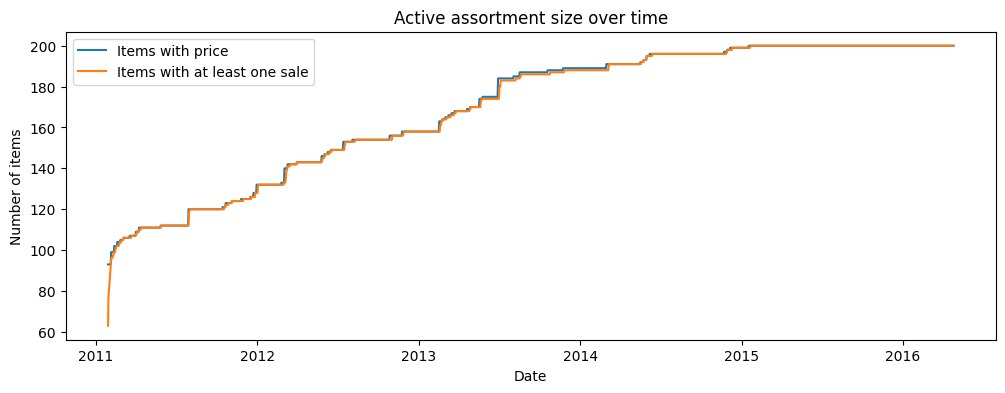

In [54]:
# Count of items that have been "introduced" (have a price) and "selling" (have had a sale) by date


def _first_date(g, condition):
    subset = g.loc[condition]
    return subset["date"].min() if len(subset) > 0 else pd.NaT


intro_local = (
    df.groupby(["store_id", "item_id"])
    .apply(
        lambda g: pd.Series(
            {
                "first_price_date": _first_date(g, g["sell_price"].notna()),
                "first_sale_date": _first_date(g, g["sales"] > 0),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
n_with_price = np.array([(intro_local["first_price_date"] <= d).sum() for d in dates])
n_with_sale = np.array(
    [(intro_local["first_sale_date"].dropna() <= d).sum() for d in dates]
)
plt.figure(figsize=(12, 4))
plt.plot(dates, n_with_price, label="Items with price")
plt.plot(dates, n_with_sale, label="Items with at least one sale")
plt.title("Active assortment size over time")
plt.xlabel("Date")
plt.ylabel("Number of items")
plt.legend()
plt.show()

In [55]:
missing_table = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": df.isna().mean().mul(100)}
)

missing_table = missing_table.round(2).sort_values("missing_pct", ascending=False)

missing_table[missing_table["missing_pct"] > 0]

,missing_count,missing_pct
event_type_2,381800,99.79
event_name_2,381800,99.79
event_name_1,351800,91.95
event_type_1,351800,91.95
sell_price,58576,15.31


In [56]:
df.groupby(df["sell_price"].isna())["sales"].describe()

,count,mean,std,min,25%,50%,75%,max
sell_price,,,,,,,,
False,324024.0,1.577362,3.1305,0.0,0.0,0.0,2.0,72.0
True,58576.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'Share of missing prices over time'}, xlabel='date'>

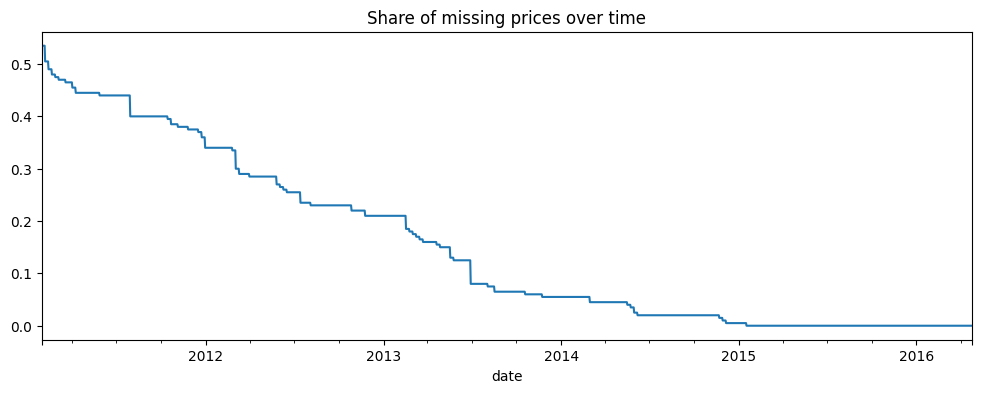

In [57]:
(
    df.assign(price_missing=df["sell_price"].isna())
    .groupby("date")["price_missing"]
    .mean()
    .plot(title="Share of missing prices over time", figsize=(12, 4))
)

In [58]:
plt.savefig(FIG_DIR / "Share of missing prices over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [59]:
df.assign(price_missing=df["sell_price"].isna()).groupby("price_missing")["sales"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
price_missing,,,
False,324024,1.577362,0.0
True,58576,0.000000,0.0


### sell_price null validation (product introduction hypothesis)

Hypothesis: null `sell_price` occurs because the product was not yet in the catalog at that date. The M5 `sell_prices.csv` has one row per `(store_id, item_id, wm_yr_wk)` only when the product has a price for that week; products introduced later have no price row for early weeks, so the left join yields null.

In [60]:
# Per-product first price date and first sale date


def _first_date(g, condition):
    subset = g.loc[condition]
    return subset["date"].min() if len(subset) > 0 else pd.NaT


intro = (
    df.groupby(["store_id", "item_id"])
    .apply(
        lambda g: pd.Series(
            {
                "first_price_date": _first_date(g, g["sell_price"].notna()),
                "first_sale_date": _first_date(g, g["sales"] > 0),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

# All null-price rows should be strictly before first_price_date for that product
null_rows = df[df["sell_price"].isna()].copy()
merged = null_rows.merge(intro, on=["store_id", "item_id"])
nulls_before_first_price = (merged["date"] < merged["first_price_date"]).sum()
total_nulls = len(null_rows)

print("Hypothesis check: null sell_price occurs only before product introduction")
print(f"  Rows with null sell_price: {total_nulls}")
print(f"  Of those, date < first_price_date: {nulls_before_first_price}")
print(f"  Match (100% expected): {nulls_before_first_price == total_nulls}")

# Overlap: first_price_date vs first_sale_date
intro_valid = intro.dropna(subset=["first_price_date", "first_sale_date"])
same_or_earlier = (
    intro_valid["first_price_date"] <= intro_valid["first_sale_date"]
).sum()
print("\nFirst price vs first sale (products with both):")
print(f"  first_price_date <= first_sale_date: {same_or_earlier} / {len(intro_valid)}")

Hypothesis check: null sell_price occurs only before product introduction
  Rows with null sell_price: 58576
  Of those, date < first_price_date: 58576
  Match (100% expected): True

First price vs first sale (products with both):
  first_price_date <= first_sale_date: 200 / 200


### Missing data summary

Key observations:
- Event-related features are highly sparse (e.g., `event_type_2` missing ~99.8%), which is expected because most days have no events.
- `sell_price` is missing for a meaningful subset of rows (~15.3%).

Interpretation:
- Event missingness is structural ("no event") rather than data quality failure.
- **Null `sell_price` is structural**: validation above confirms that 100% of null-price rows occur at dates *before* the product's first price date. The M5 `sell_prices.csv` has a row only when a product is actively sold in that week; products introduced later have no price for early weeks, so the left join yields null. Rows with null price have zero sales (product not yet in catalog).

Decision:
- Encode event missingness as an explicit "no event" category (or boolean flags).
- Keep null `sell_price` as "no price" (or let the model treat it as a distinct category via `use_missing`) rather than imputing; filling with 0 or mean would misrepresent "not yet introduced."


## 5.3 Structural breaks / single-series spot check

Inspect one or a few series: zero regimes, introduction, price overlay, events.

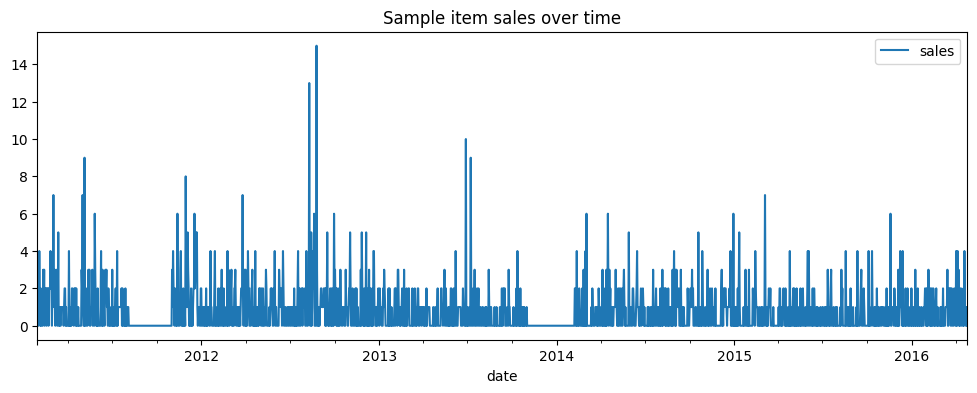

In [61]:
sample_key = df.loc[df["sales"] > 0, ["store_id", "item_id"]].drop_duplicates().iloc[0]

mask = (df["store_id"] == sample_key["store_id"]) & (
    df["item_id"] == sample_key["item_id"]
)

df.loc[mask].plot(x="date", y="sales", figsize=(12, 4))
plt.title("Sample item sales over time")
plt.show()

In [62]:
plt.savefig(FIG_DIR / "Sample item sales over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

# 7. Price & Exogenous Drivers

## 7.1 Price distribution
(Inspect sell_price; see missingness section.)

## 7.2 Price–sales relationship
Scatter (log scale optional); within-item correlation. Below: daily scatter then weekly / two-part / quantiles.


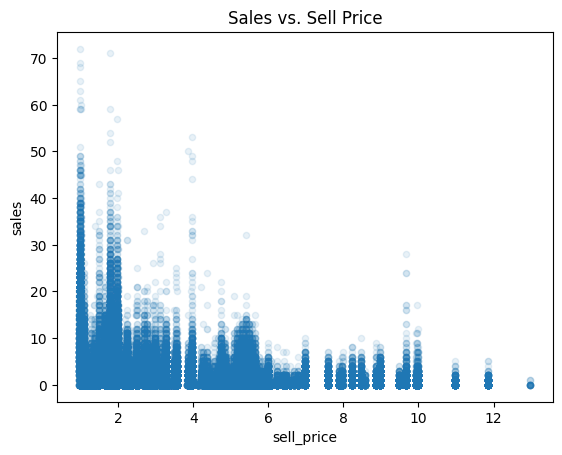

In [63]:
df.plot.scatter(x="sell_price", y="sales", alpha=0.1)
plt.title("Sales vs. Sell Price")
plt.show()

In [64]:
plt.savefig(FIG_DIR / "Sales vs Sell Price", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

**Observation**
- Relationship appears weak at the daily level.
- High variance suggests price elasticity may operate over longer horizons.

**Decision**
- Retain price as a feature.
- Avoid strong assumptions about linear price elasticity.

Note: price-demand relationships are typically clearer at aggregated levels (weekly or category/store) and with controls for seasonality/events; daily scatter may look noisy even when elasticity exists.


## 7.2 (continued) Weekly aggregation, two-part, price quantiles

Weekly sales vs price; P(sale) and median(sales|>0) by within-item price quintile.

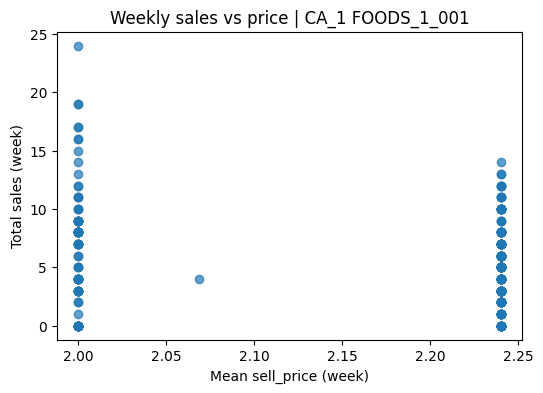

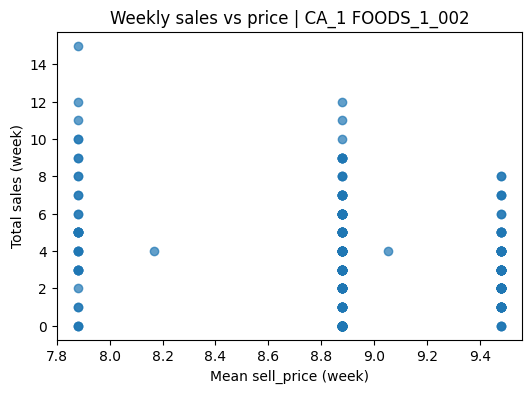

In [65]:
# Weekly aggregation: sales and price by (store_id, item_id, week)
df_weekly = (
    df.assign(
        week=df["date"].dt.isocalendar().week, year=df["date"].dt.isocalendar().year
    )
    .groupby(["store_id", "item_id", "year", "week"], as_index=False)
    .agg(sales=("sales", "sum"), sell_price=("sell_price", "mean"))
)
df_weekly = df_weekly.dropna(subset=["sell_price"])
# Scatter: weekly sales vs weekly mean price (sample of series for readability)
sample_ids = (
    df_weekly.groupby(["store_id", "item_id"]).size().nlargest(3).index.tolist()
)
for sid, iid in sample_ids[:2]:
    w = df_weekly[(df_weekly["store_id"] == sid) & (df_weekly["item_id"] == iid)]
    plt.figure(figsize=(6, 4))
    plt.scatter(w["sell_price"], w["sales"], alpha=0.7)
    plt.title(f"Weekly sales vs price | {sid} {iid}")
    plt.xlabel("Mean sell_price (week)")
    plt.ylabel("Total sales (week)")
    plt.show()

In [68]:
# Two-part: P(sale > 0) and median(sales | sale > 0) by price quantile (within item)
df_valid_price = df.dropna(subset=["sell_price"])
df_valid_price["has_sale"] = (df_valid_price["sales"] > 0).astype(int)
# Within each (store_id, item_id), assign price quintile
df_valid_price["price_q"] = df_valid_price.groupby(["store_id", "item_id"])[
    "sell_price"
].transform(lambda x: pd.qcut(x, 5, labels=False, duplicates="drop"))
two_part = df_valid_price.groupby(
    ["store_id", "item_id", "price_q"], as_index=False
).agg(p_sale=("has_sale", "mean"), median_sale=("sales", lambda s: s[s > 0].median()))
two_part_summary = (
    two_part.groupby("price_q")
    .agg(p_sale=("p_sale", "mean"), median_sale=("median_sale", "median"))
    .reset_index()
)
print(
    "Across items: average P(sale) and median(sales|>0) by within-item price quintile"
)
print(two_part_summary.to_string(index=False))

C:\Users\imanb\AppData\Local\Temp\ipykernel_35876\2308504022.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid_price["has_sale"] = (df_valid_price["sales"] > 0).astype(int)
C:\Users\imanb\AppData\Local\Temp\ipykernel_35876\2308504022.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid_price["price_q"] = df_valid_price.groupby(["store_id", "item_id"])["sell_price"].transform(


Across items: average P(sale) and median(sales|>0) by within-item price quintile
 price_q   p_sale  median_sale
     0.0 0.456761          2.0
     1.0 0.418779          1.0
     2.0 0.325672          1.0
     3.0 0.261053          1.0
     4.0 0.144529          1.0


## 7.3 Promotion / event effects

Mean sales by event; event counts; uplift vs matched non-event days (same weekday).

In [19]:
df.groupby("event_name_1")["sales"].mean().sort_values(ascending=False).head(10)

event_name_1
ValentinesDay     1.918333
Easter            1.804000
Chanukah End      1.547000
Eid al-Fitr       1.484000
LaborDay          1.451000
Father's day      1.400000
MemorialDay       1.386000
Ramadan starts    1.372000
OrthodoxEaster    1.362500
Mother's day      1.357000
Name: sales, dtype: float64

(Event impact with controls: counts per event; uplift vs same-weekday non-event baseline.)

## 7.4 SNAP / policy effects
Calendar SNAP flags and other policy drivers (if present) can be correlated with demand.

**Output: Elasticity & exogenous influence assessment.**

In [69]:
# Counts per event (sample size for interpretation)
event_counts = (
    df.groupby("event_name_1", dropna=False)
    .agg(
        count=("sales", "count"),
        mean_sales=("sales", "mean"),
    )
    .sort_values("count", ascending=False)
)
print("Event name: count of observations and mean sales")
print(event_counts.head(15).to_string())

# Matched comparison: event vs non-event same weekday
df_ev = df.copy()
df_ev["dow"] = df_ev["date"].dt.dayofweek
df_ev["is_event"] = df_ev["event_name_1"].notna()
non_event_mean_by_dow = (
    df_ev.loc[~df_ev["is_event"]].groupby("dow")["sales"].mean().to_dict()
)
df_ev["non_event_baseline"] = df_ev["dow"].map(non_event_mean_by_dow)
event_lift = (
    df_ev.loc[df_ev["is_event"]]
    .groupby("event_name_1")
    .agg(
        mean_sales=("sales", "mean"),
        baseline=("non_event_baseline", "mean"),
        n=("sales", "count"),
    )
    .assign(
        lift_pct=lambda x: (x["mean_sales"] - x["baseline"])
        / (x["baseline"] + 1e-6)
        * 100
    )
)
print("\nEvent vs same-weekday non-event baseline (lift %):")
print(event_lift.sort_values("lift_pct", ascending=False).head(10).to_string())

Event name: count of observations and mean sales
                      count  mean_sales
event_name_1                           
NaN                  351800    1.343403
LentStart              1200    1.225000
LentWeek2              1200    1.070000
SuperBowl              1200    1.299167
Purim End              1200    1.325833
PresidentsDay          1200    1.118333
StPatricksDay          1200    1.298333
ValentinesDay          1200    1.918333
EidAlAdha              1000    1.301000
MartinLutherKingDay    1000    1.221000
Chanukah End           1000    1.547000
Eid al-Fitr            1000    1.484000
Easter                 1000    1.804000
Christmas              1000    0.000000
ColumbusDay            1000    1.169000

Event vs same-weekday non-event baseline (lift %):
                     mean_sales  baseline     n   lift_pct
event_name_1                                              
ValentinesDay          1.918333  1.370874  1200  39.935003
Chanukah End           1.547000  1.241682 

# 5. Temporal Structure

## 5.1 Seasonality
Weekly (DOW), monthly, event-driven patterns.

## 5.2 Trend
Rolling means; aggregate daily sales.

## 5.3 Structural breaks
Zero regimes, introduction dates, assortment growth. Below: item-level series spot check.

**Output: Stationarity assessment.**

Selected series: CA_1 FOODS_1_019 | Non-zero days: 1008
Observations: 1913
Zero-sales rate: 0.473
Mean sales: 4.052 | Std sales: 5.255
Avg gap between non-zero days: 1.8987090367428003


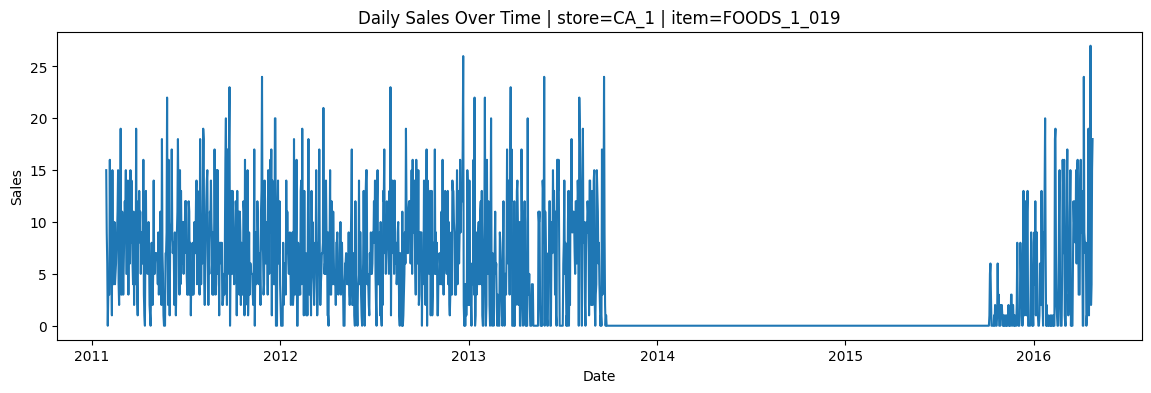

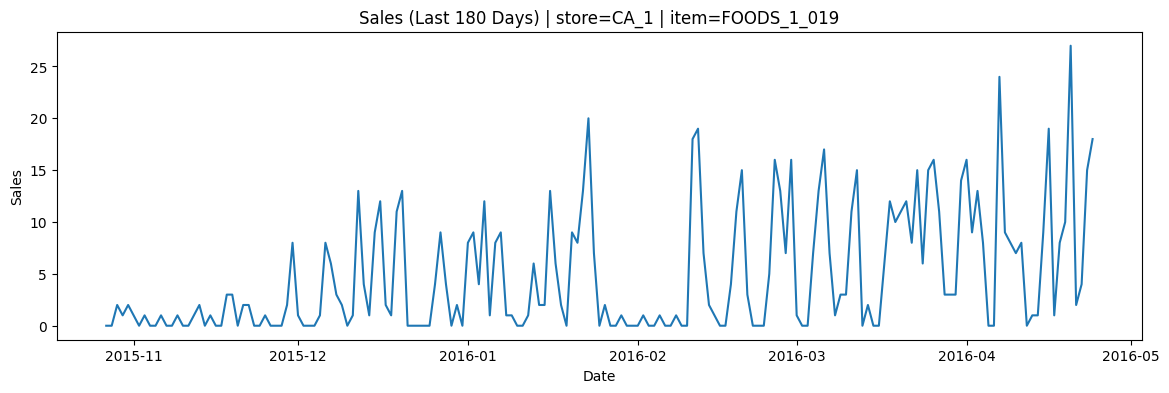

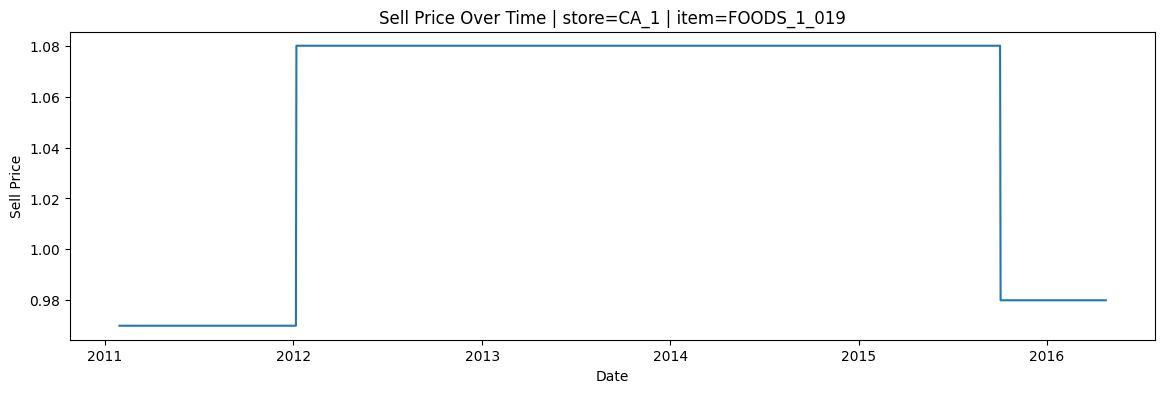

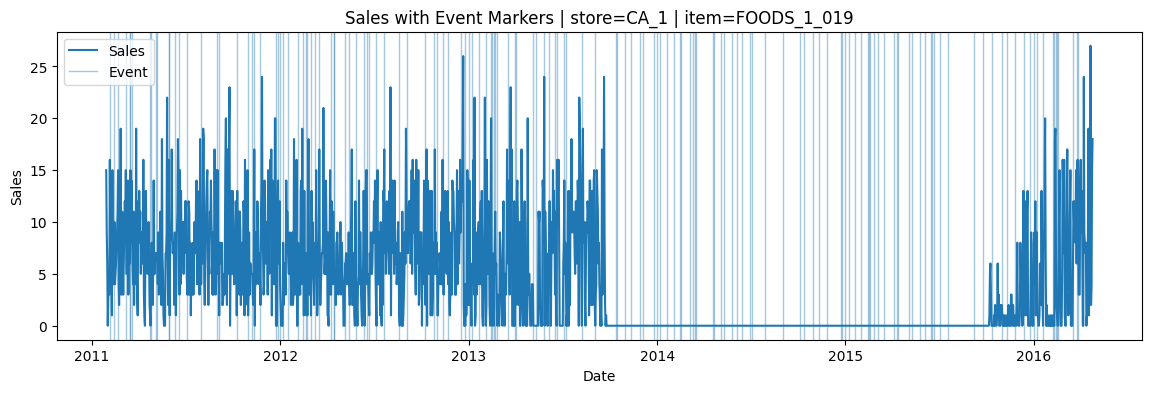

In [20]:
# Basic key sanity checks
required_cols = {"store_id", "item_id", "date", "sales"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Pick a representative series:
# - choose a (store, item) with at least N non-zero days (so it's not all zeros)
min_nonzero_days = 30
seed = 42
rng = np.random.default_rng(seed)

series_stats = (
    df.assign(nonzero=(df["sales"] > 0).astype(int))
    .groupby(["store_id", "item_id"])["nonzero"]
    .sum()
)

eligible = series_stats[series_stats >= min_nonzero_days]
if eligible.empty:
    raise ValueError(
        "No eligible series; reduce min_nonzero_days or increase sample size."
    )

# pick one eligible series at random, but reproducible
idx = rng.integers(0, len(eligible))
store_id, item_id = eligible.index[idx]
print(
    "Selected series:", store_id, item_id, "| Non-zero days:", int(eligible.iloc[idx])
)

ts = (
    df[(df["store_id"] == store_id) & (df["item_id"] == item_id)]
    .sort_values("date")
    .reset_index(drop=True)
)

# --- Quantify intermittency / burstiness ---
n = len(ts)
zero_rate = (ts["sales"] == 0).mean()
mean_sales = ts["sales"].mean()
std_sales = ts["sales"].std()

# Average gap length between non-zero sales
nz_dates = ts.loc[ts["sales"] > 0, "date"]
avg_gap_days = nz_dates.diff().dt.days.dropna().mean() if len(nz_dates) > 1 else None

print(f"Observations: {n}")
print(f"Zero-sales rate: {zero_rate:.3f}")
print(f"Mean sales: {mean_sales:.3f} | Std sales: {std_sales:.3f}")
print(
    f"Avg gap between non-zero days: {avg_gap_days if avg_gap_days is not None else 'N/A'}"
)

# --- Plot sales over time ---
plt.figure(figsize=(14, 4))
plt.plot(ts["date"], ts["sales"])
plt.title(f"Daily Sales Over Time | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# --- zoomed view ---
last_n_days = 180
ts_zoom = ts[ts["date"] >= (ts["date"].max() - pd.Timedelta(days=last_n_days))]

plt.figure(figsize=(14, 4))
plt.plot(ts_zoom["date"], ts_zoom["sales"])
plt.title(f"Sales (Last {last_n_days} Days) | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ---overlay sell_price ---
if "sell_price" in ts.columns:
    plt.figure(figsize=(14, 4))
    plt.plot(ts["date"], ts["sell_price"])
    plt.title(f"Sell Price Over Time | store={store_id} | item={item_id}")
    plt.xlabel("Date")
    plt.ylabel("Sell Price")
    plt.show()

# ---event marker view---
if "event_name_1" in ts.columns:
    event_days = ts.loc[ts["event_name_1"].notna(), "date"]
    plt.figure(figsize=(14, 4))
plt.plot(ts["date"], ts["sales"], label="Sales")

event_days = ts.loc[ts["event_name_1"].notna(), "date"]
if len(event_days) > 0:
    first = True
    for d in event_days:
        plt.axvline(d, linewidth=1, alpha=0.4, label="Event" if first else None)
        first = False

plt.title(f"Sales with Event Markers | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


### 5.3 Example: structural regime shift & lifecycle

Prolonged zero-sales (e.g. 2014–2015) often reflects product unavailability (structural break). Lifecycle: active → inactive → reintroduction. Price stepwise; variance scales with level (count-like, heteroskedastic).

---

# 9. Modeling Implications

Connect EDA to modeling decisions:

* **Gaussian inappropriate because:** sparsity, skewness, zero-inflation, heteroskedasticity, regime shifts.
* **Zero-inflation requires:** count or two-part models; availability indicator to separate structural vs demand zeros.
* **Intermittency suggests:** flexible (e.g. tree-based or count-aware) methods; avoid strong linear/smooth assumptions.
* **Availability feature required** for backtesting and evaluation.
* **Time-aware backtesting** necessary (cutoff by date; respect introduction and assortment growth).
* **Metric choice:** prefer MAE or sMAPE over RMSE for sparse demand.


## 5.2 Trend (store-level aggregate)

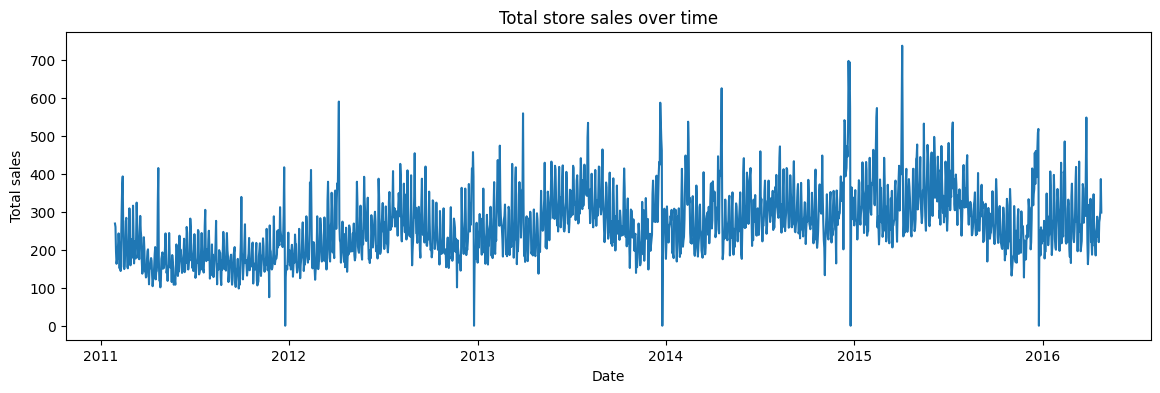

In [ ]:
# --- Total store sales over time ---
store_daily = df.groupby("date")["sales"].sum().sort_index()

plt.figure(figsize=(14, 4))
plt.plot(store_daily.index, store_daily.values)
plt.title("Total store sales over time")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

In [84]:
plt.savefig(FIG_DIR / "Total store sales over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

## 5.1 Seasonality (day-of-week)

## 5.1 (continued) Seasonality beyond day-of-week

Week-of-year and month-of-year; ACF at lags 7, 28.

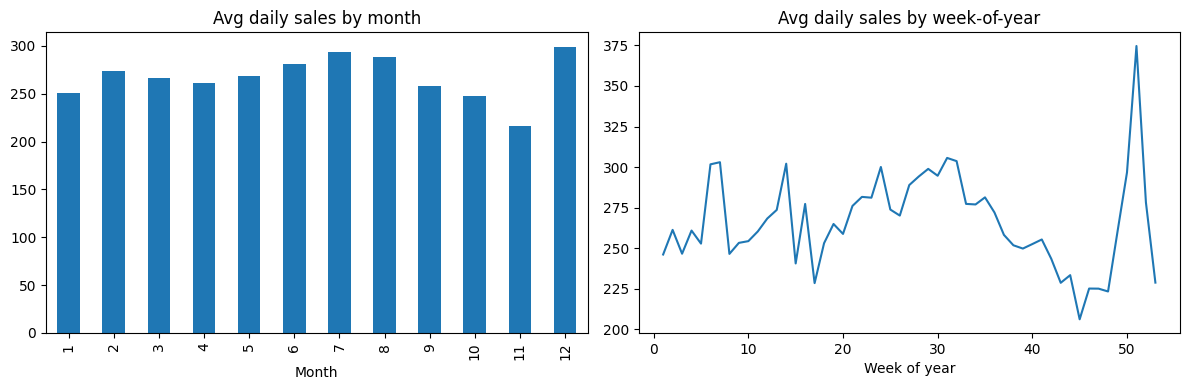

In [70]:
# Month-of-year and week-of-year (store-level total sales)
store_daily = df.groupby("date")["sales"].sum()
store_daily = store_daily.reindex(
    pd.date_range(store_daily.index.min(), store_daily.index.max(), freq="D")
).fillna(0)
store_daily = store_daily.reset_index().rename(columns={"index": "date"})
store_daily["month"] = store_daily["date"].dt.month
store_daily["week_of_year"] = store_daily["date"].dt.isocalendar().week.astype(int)
by_month = store_daily.groupby("month")["sales"].mean()
by_week = store_daily.groupby("week_of_year")["sales"].mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
by_month.plot(kind="bar", ax=ax1, title="Avg daily sales by month")
ax1.set_xlabel("Month")
by_week.plot(ax=ax2, title="Avg daily sales by week-of-year")
ax2.set_xlabel("Week of year")
plt.tight_layout()
plt.show()

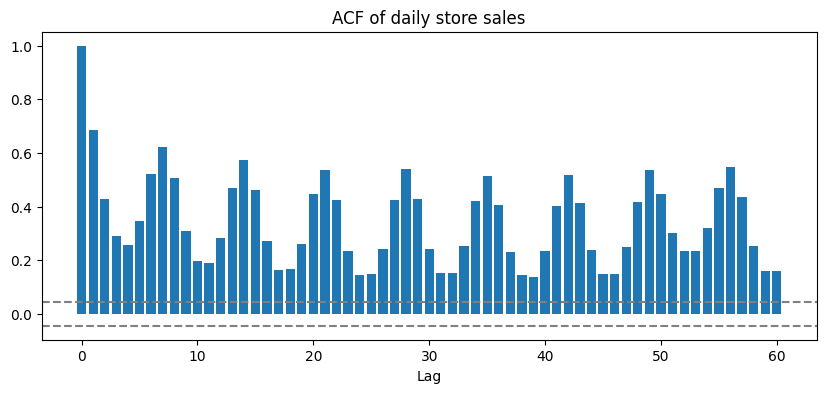

Notable lags (e.g. 7, 14, 28) suggest weekly/monthly structure for features.


In [71]:
# ACF at lags 7, 28 (store-level series)
try:
    from statsmodels.graphics.tsaplots import plot_acf

    plot_acf(
        store_daily["sales"].values,
        lags=60,
        alpha=0.05,
        title="ACF of daily store sales",
    )
    plt.xlabel("Lag")
    plt.show()
except ImportError:
    x = store_daily["sales"].values - store_daily["sales"].mean()
    n = len(x)
    acf = np.array(
        [
            np.correlate(x[: n - k], x[k:n], mode="valid")[0] / (n * (x.var() or 1))
            for k in range(61)
        ]
    )
    plt.figure(figsize=(10, 4))
    plt.bar(range(61), acf, width=0.8)
    plt.axhline(y=1.96 / np.sqrt(n), color="gray", linestyle="--")
    plt.axhline(y=-1.96 / np.sqrt(n), color="gray", linestyle="--")
    plt.title("ACF of daily store sales")
    plt.xlabel("Lag")
    plt.show()
print("Notable lags (e.g. 7, 14, 28) suggest weekly/monthly structure for features.")

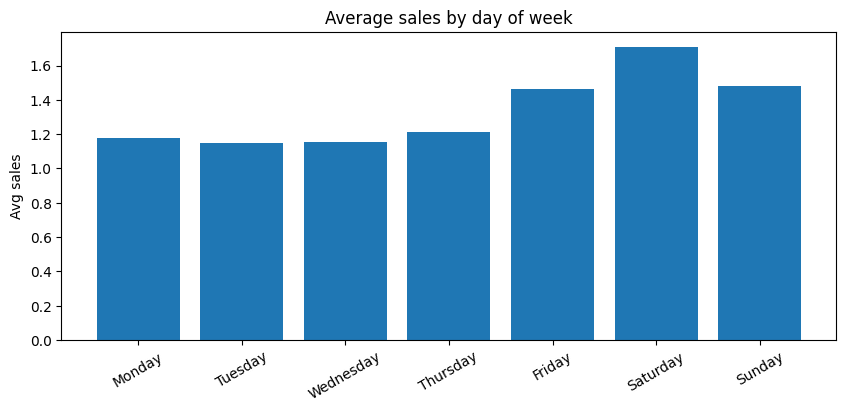

In [73]:
dow = df.assign(dow=df["date"].dt.day_name()).groupby("dow")["sales"].mean()
# order by weekday
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = dow.reindex(order)

plt.figure(figsize=(10, 4))
plt.bar(dow.index, dow.values)
plt.title("Average sales by day of week")
plt.xticks(rotation=30)
plt.ylabel("Avg sales")
plt.show()

In [74]:
plt.savefig(FIG_DIR / "Average sales by day of week", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [75]:
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Delayed labels (as-of evaluation)

In real systems, sales for date $D$ are often observed only after a delay (e.g. $D+1$ or $D+7$). For **as-of** training and evaluation: at cutoff date $T$, only targets with **observation date** $\\leq T$ should be used; no future leakage. Below we document the concept and show label coverage when a delay is assumed (e.g. 0 or 1 day).

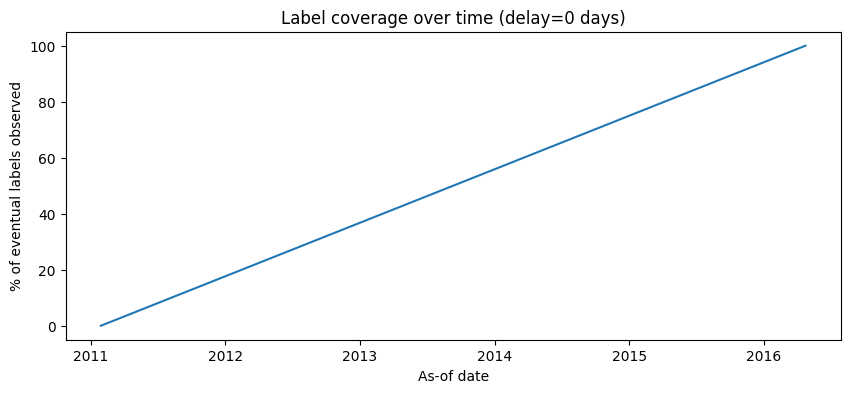

For backtesting: train only on rows with obs_date <= cutoff; evaluate on horizon after cutoff.


In [76]:
# Assume a fixed delay (days) after which the label is observed. 0 = same-day observation.
LABEL_DELAY_DAYS = 0  # change to 1 or 7 to simulate delayed labels
df["obs_date"] = df["date"] + pd.Timedelta(days=LABEL_DELAY_DAYS)
# At each possible "as-of" date T, how many (store, item, date) targets are observable?
as_of_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="7D")  # weekly
coverage = [
    (t, (df["obs_date"] <= t).sum(), (df["obs_date"] <= t).mean() * 100)
    for t in as_of_dates
]
cov_df = pd.DataFrame(coverage, columns=["as_of_date", "n_observed", "pct_observed"])
plt.figure(figsize=(10, 4))
plt.plot(cov_df["as_of_date"], cov_df["pct_observed"])
plt.title(f"Label coverage over time (delay={LABEL_DELAY_DAYS} days)")
plt.xlabel("As-of date")
plt.ylabel("% of eventual labels observed")
plt.show()
print(
    "For backtesting: train only on rows with obs_date <= cutoff; evaluate on horizon after cutoff."
)

# 10. Summary & Risk Assessment

* **Data quality status:** Schema and key uniqueness validated; structural missingness (price, introduction) documented.
* **Structural risks:** Non-stationary assortment; early zeros from introduction; price stepwise and sparse.
* **Modeling challenges:** Zero-inflation; intermittency; heterogeneity across series; regime shifts.
* **Business implications:** Typical intermittent retail demand; need availability-aware evaluation and robust metrics.

---

# Optional advanced (senior-level)

* Change-point detection
* Hierarchical aggregation consistency
* Demand clustering
* ADI–CV² quadrant plot
* Leakage risk audit
